## Dropout Regularizer

In [3]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [4]:
class DropoutNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Linear(3072, 512),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, 10)
        )
    def forward(self, x):
        return self.features(x)

model = DropoutNet()

In [6]:
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
losses = []

model.train()
for epoch in range(10):
    running_loss = 0
    for images, labels in train_loader:
        images = images.view(images.size(0), -1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    epoch_loss = running_loss / len(train_loader)
    losses.append(epoch_loss)
    print(f"Epoch: {epoch+1}, Loss: {epoch_loss:.5f}")

Epoch: 1, Loss: 1.89189
Epoch: 2, Loss: 1.87838
Epoch: 3, Loss: 1.86710
Epoch: 4, Loss: 1.85657
Epoch: 5, Loss: 1.84647
Epoch: 6, Loss: 1.83577
Epoch: 7, Loss: 1.83203
Epoch: 8, Loss: 1.82656
Epoch: 9, Loss: 1.82504
Epoch: 10, Loss: 1.81362


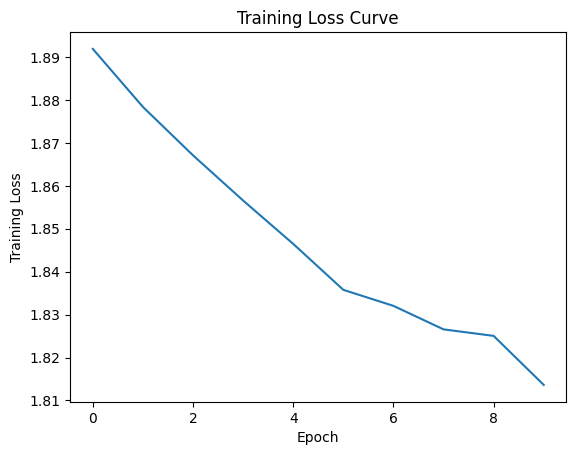

In [7]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.show()